In [1]:
import pandas as pd
import numpy as np

import seaborn as sns

import pathlib, sys
base_path = pathlib.Path().resolve().parents[1]
PROJECT_ROOT = pathlib.Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import paths
import helpers.utils as utils

df = pd.read_csv(f'{paths.DATA_PATH}/global_trials_7b.csv', sep = ',')


Utils excecuted


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_64484/458757948.py:13: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{paths.DATA_PATH}/global_trials_7b.csv', sep = ',')


In [10]:
print(df[df['ttype_c']=='SIL'].groupby('subject').size())

subject
A45     78
A46    829
A48    119
A49    322
dtype: int64


In [40]:
fixation_columns = [col for col in df.columns if 'Port' in col]
print(fixation_columns)

[]


In [ ]:
dfs = [df]

# to_convert_columns = ['response_x', 'response_y', 
#                    'STATE_Incorrect_START',
#                    'STATE_Fixation_START', 
#                    'STATE_Response_window_START',
#                    'STATE_Response_window2_START', 'STATE_Response_window2_END',
#                    'PA1_Port1In_START','PA1_Port2In_START', 'PA1_Port3In_START','Port4In_START', 'Port2In_START'] # rats: 'Port2In_START'

for idx, df in enumerate(dfs):
    df['day'] = pd.to_datetime(df['date']).dt.date # INCLUDE DAY COLUMN IN A DATATIME FORMAT

    # Check if columns exist in the df & has a list of values    
    valid_columns = [column for column in to_convert_columns if column in df.columns 
                     and df[column].dtype == 'O' and df[column].str.contains(',').any()]
    
    # Apply conversion to valid columns
    df = utils.convert_strings_to_lists(df, valid_columns)   # CONVERT STRING TO LISTS
    
    # Assign the modified dataframe back to the original dataframe
    globals()[f'df{idx+3}'] = df  # Since df3 is the first dataframe, idx+3 gives the correct name
df['batch']= '7B'
# df['STATE_Fixation1_START_last'] = df.apply(utils.find_last_before, x='PA1_Port1In_START',y='STATE_Fixation2_START', z='STATE_Fixation1_START', axis=1)    
# df['STATE_Fixation2_START_last'] = df.apply(utils.find_last_before, x='Port2In_START',y='STATE_Fixation3_START', z='STATE_Fixation2_START', axis=1)    
# df['STATE_Fixation3_START_last'] = df.apply(utils.find_last_before, x='PA1_Port3In_START',y='STATE_Response_window_START', z='STATE_Fixation3_START', axis=1)

for idx, df in enumerate(dfs):
    df['total_trials']= df.groupby(['subject','session'])['trial'].transform(lambda x: x.max()) # INCLUDE nºTOTAL TRIALS/SESSION
    df['maze_version'] = 'corridor' # INCLUDE MAZE VERSION (PREVIOUSLY CLASSIC VS TMAZE)
    df['relative_weights'] = df.apply(lambda x: utils.relative_weights(x['subject'], x['subject_weight']), axis=1)
    
    # correct for df3
    if idx==0:
        df.loc[df['box']==1, 'maze_version'] = 'door'
    
    # Extract timestams of the first & last response
    df['response_x_first'] = df['response_x'].apply(lambda x: x[0] if len(x) > 0 else None)
    df['response_x_last']  = df['response_x'].apply(lambda x: x[-1]if len(x) > 0 else None)
    df['response_y_first'] = df['response_y'].apply(lambda x: x[0] if len(x) > 0 else None)
    df['response_y_last']  = df['response_y'].apply(lambda x: x[-1] if len(x) > 0 else None)

df['ttype_n'] = df['trial_type'].replace(['VG','DS','DSc1', 'DSc2', 'DM','DMc1','DL'],[0, 1,1,1, 2,2, 3])  # Stim dur variations
df['ttype_c'] = df['trial_type'].replace(['VG','DS','DSc1', 'DSc2', 'DM','DMc1','DL'],['VG','DS','DS', 'DS', 'DM','DM','DL'])
df['stimd_n'] = df['trial_type'].replace(['VG','DS','DSc1', 'DSc2', 'DM','DMc1','DL'],[4, 3, 2, 1,2, 1,1]) 
df['stimd_c'] = df['trial_type'].replace(['VG','DS','DSc1', 'DSc2', 'DM','DMc1','DL'],['VG','SL', 'SM', 'SS', 'SM','SS', 'SS'])

df = df.loc[((df['stage']>2) | ((df['stage']==2) | (df['substage']==3)))] 


for idx, df in enumerate(dfs):
    
    # FIRST/LAST RESPONSE TIME (From response window onset)
    df['responses_time'] = df.apply(lambda row: utils.create_responses_time(row), axis=1)
    df['response_time_first'] = df['responses_time'].apply(lambda x: x[0] if len(x) > 0 else None)
    df['response_time_last']  = df['responses_time'].apply(lambda x: x[-1] if len(x)> 0 else None)
    
    # RESPONSE WINDOW END
    df['STATE_Response_window2_END'] = df['STATE_Response_window2_END'].apply(lambda x: [np.nan] if len(x) == 0 else x) #add nans to empty list, if not error
    df['response_window_end'] = df['STATE_Response_window2_END'].apply(lambda x: x[-1])
    df['response_window_end'] = df['response_window_end'].fillna(df['STATE_Response_window_END'])
    if idx==5: #df8 (has extra response window without laser ON)
        df['response_window_end'] = df['STATE_Response_window_finish_END'].fillna(df['response_window_end'])
    
    # REWARD TIME (Lickport after corrct; PH1 after punish-incorrect-miss) 
    df['reward_time'] = df['STATE_Correct_first_reward_START'].fillna(0) + df[
    'STATE_Correct_other_reward_START'].fillna(0) + df['STATE_Miss_reward_START'].fillna(0)

    
    df['resp_latency'] = df['response_time_first'] - df['STATE_Response_window_START'] #FIRST RESPONSE 
    df['lick_latency'] = df['reward_time'] - df['response_window_end']
    df['corridor_latency'] = df['STATE_Response_window_START'] - df['STATE_Fixation1_START_last']

df['delay_abs'] = 0  #FOR VG
df.loc[df['ttype_c']=='DS', 'delay_abs'] = np.maximum(df['response_time_first'] -  (df['STATE_Response_window_START'] + df['stim_dur_ds']), 0) #Timer from resp
df.loc[df['ttype_c']=='DM', 'delay_abs'] = df['response_time_first'] - np.minimum((df['STATE_Fixation3_START'] + df['stim_dur_dm']), df['STATE_Response_window_START']) #Timer from PH3 (corrected by respwin onset)
df.loc[df['ttype_c']=='DL', 'delay_abs'] = df['response_time_first'] - np.minimum((df['STATE_Fixation2_START'] + df['stim_dur_dl']), df['STATE_Fixation3_START']) #Timer from PH2 (corrected by fixation3)

df['delay_rw'] =  None  #FOR VG
df.loc[df['ttype_c']=='DS', 'delay_rw'] =  0  #FOR WMI
df.loc[df['ttype_c']=='DM', 'delay_rw'] = np.maximum(df['STATE_Response_window_START']- (df['STATE_Fixation3_START'] + df['stim_dur_dm']), 0) 
df.loc[df['ttype_c']=='DL', 'delay_rw'] = df['STATE_Response_window_START']- np.minimum((df['STATE_Fixation2_START'] + df['stim_dur_dl']), df['STATE_Fixation3_START']) 




KeyError: 'PA1_Port1In_START'

In [63]:
df['genotype'] = 'WT'
df['bias_prob'] = df['bias_prob_vector'].fillna(df['bias_prob_vector']) # homogenize bias_prob columns form V3 & V4
df['injection'] = 'Rest' 
df['virus'] = None
df['4OHT_label'] = None
df['opto_on'] = 0
df['opto_bool'] = 0
df['frequency'] = None
df['opto_delay'] = None
df['max_dur_light'] = None
df=df.loc[~((df['date']>='2023/09/16') & (df['date']<='2023/09/23'))]  #remove touchscreen detection probelms
df= df.loc[((df['subject']!='A85') & (df['subject']!='A94') & (df['subject']!='A97'))] # never learn


final_columns = ['subject', 'date', 'batch', 'task', 'stage', 'substage', 'session', 'trial', 'total_trials', 
                 'subject_weight', 'relative_weights',
    
                  'y', 'x','response_x_first', 'response_x_last', 'response_y_first', 'response_y_last', 'mask',
                 
                 'trial_type', 'ttype_n', 'ttype_c', 'stimd_n', 'stimd_c', 'delay_abs', 'delay_rw', 
                 'stim_dur_ds', 'stim_dur_dm', 'stim_dur_dl',
                
                 'trial_result',  
                 'response_time_first', 'response_time_last', 'response_window_end', 'reward_time',
                 'corridor_latency', 'resp_latency', 'lick_latency', 'trial_length', 
                 
                 'STATE_Start_task_START', 'STATE_Fixation1_START', 'STATE_Fixation2_START', 
                 'STATE_Fixation3_START','STATE_Response_window_START' ,'STATE_Response_window_END', 
                 'STATE_Exit_START',
                 'bias_prob','bias_side', 'stim_prob_block_size', 'block_trial_counter',
                 'STATE_Fixation1_START_last','STATE_Fixation2_START_last', 'STATE_Fixation3_START_last',
                 'STATE_Fixation3_END',
                 'correction_bias', 'STATE_Exit_END',]

subset_9b =df[final_columns]
df = subset_9b

# Perfromance and Misses calculation
df['performance']= np.where(df['trial_result'] == 'correct_first', 1, 0)
df['accuracy'] = df['performance']
df.loc[(df.trial_result == 'miss', 'accuracy')] = np.nan #no misses in accuracy
df['misses']=np.where(df['trial_result'] == 'miss', 1, 0)

# Silent trials
df['silent']= df.apply(lambda x: 1 if x['y']== 1000 else 0, axis=1)
df.loc[df['silent']==1, 'ttype_n']=4
df.loc[df['silent']==1, 'ttype_c']='SIL'
df.loc[df['silent']==1, 'stimd_n']=0
df.loc[df['silent']==1, 'stimd_c']='SIL'

# chance
df['chance']= 1/df['mask']

# Categorize stimulus positions for MASK == 3
df['x_n']=np.nan

# caution rats have 60:L 175:C, 290:R
bins_x_all=[24.0, 44.0, 
            60.0, 65.0, 113.0, 123.5,
            175, 200.0, 202.0, 203.0, 
            282.5,  291.0, 335.0, 340.0, 
            290,  362.0, 380.0]
numbers_x_all=[-2, -2, 
              -1, -1, -1, -1,
              0, 0, 0, 0,
              1, 1, 1, 1,
              2, 2, 2]
labels_x_all= ['LL', 'L', 'C', 'R', 'RR']

df['x_n'] = df['x'].replace(bins_x_all,numbers_x_all)
df['x_c'] = df['x_n'].replace([-2, -1, 0, 1, 2],labels_x_all)


# Categorize response positions for MASK == 3
bins_r = pd.IntervalIndex.from_tuples([(20, 100), (160, 240), (300, 380)]) # 3 choices
numbers_r = [-1, 0, 1]
labels_r = ['L', 'C', 'R']

df['r_n']=np.nan
df['r_n'] = pd.cut(df.response_x_first, bins=bins_r, ordered=True).map(dict(zip(bins_r, numbers_r)))
df['r_n'] = df['r_n'].astype(float)
df['r_c'] = df['r_n'].replace(numbers_r,labels_r)

df['valids']=1

# NO STAGE TRAINING CODES NO VALIDS
df.loc[~df['task'].str.contains('StageTraining'), 'valids'] = 0

# MISSING STATES NO VALID TRIALS
df.loc[df['STATE_Response_window_START'].isnull(), 'valids'] = 0
df.loc[df['STATE_Response_window_END'].isnull(),  'valids']= 0
df.loc[df['STATE_Exit_START'].isnull(),  'valids']= 0

# EASY TRIALS NO VALID TRIALS
df.loc[df['trial']<10, 'valids']=0
df.loc[((df['trial']<12) & ((df['batch']=='3B') | (df['batch'] == '4B') | (df['batch'] == '5B'))), 'valids'] = 0

# REMOVE BPOD ERROR TRIALS
# df.loc[df['BPODCRASH'].notnull(), 'valids'] = 0

# REMOVE BADLY CATEGORIZED RESPONSES (OUTLIERS)
df.loc[((df['r_n'].isnull()) & (df['trial_result']!='miss')) , 'valids'] = 0

# REMOVE EMPTY RESPONSE TIME 
df.loc[((df['response_time_first'].isnull()) & (df['trial_result']!='miss')), 'valids'] = 0

# df.to_csv('global_trials_11_MK.csv', sep=';')
# Assuming df is your pandas DataFrame and columns is your list of column names
# df.to_csv('./datasets/df_filtered.csv', sep=';') 

In [33]:
print(df['date'].min(), df['date'].max())
filtered_df = df.copy()
# filtered_df = df[df['task'].isin(['StageTraining_9B_V1','StageTraining_9B_V2'])]
# filtered_df = filtered_df[((filtered_df['stage']>2) | ((filtered_df['stage']==2) & (filtered_df['substage']==3)))]  # remove stage 1 & 2 trials
# filtered_df = filtered_df[filtered_df['stim_dur_dl']==0]
print(filtered_df['task'].value_counts())
print(filtered_df.subject.value_counts())
filtered_df = filtered_df[filtered_df['misses']==0]
print(filtered_df.groupby('subject')['misses'].sum())
print(filtered_df['task'].unique())
print(filtered_df.groupby(['stage', 'substage']).size())
filtered_df['correct_bool']=filtered_df['accuracy']
# filtered_df.to_csv('./datasets/df_filtered.csv', sep=';')

2022/10/31 2023/05/18
task
StageTraining_7B_V1    60755
Name: count, dtype: int64
subject
A46    23477
A49    10386
A48     5889
A41     3933
A42     3706
A45     3136
A52     2916
A51     2765
A47     2732
A50     1354
A44      461
Name: count, dtype: int64
subject
A41    0
A42    0
A44    0
A45    0
A46    0
A47    0
A48    0
A49    0
A50    0
A51    0
A52    0
Name: misses, dtype: int64
['StageTraining_7B_V1']
stage  substage
2.0    3.0         27220
3.0    1.0         31930
dtype: int64


In [64]:
# Create timepoints by calculating differences between states
# df = pd.read_csv(f'{paths.DATA_PATH}/df_filtered_7B.csv', sep = ';')
# df =df[(df['trial_result'] == 'correct_first')|( df['trial_result'] == 'incorrect')]  # Filter for correct trials only
# df['timepoint_1'] = 0
filtered_df = df.copy()
filtered_df['timepoint_1'] = filtered_df['STATE_Fixation2_START'] - filtered_df['STATE_Fixation1_START_last']
filtered_df['timepoint_2'] = filtered_df['STATE_Fixation3_START'] - filtered_df['STATE_Fixation1_START_last']
filtered_df['timepoint_3'] = filtered_df['STATE_Response_window_START'] - filtered_df['STATE_Fixation1_START_last']
filtered_df['timepoint_4'] = filtered_df['response_time_first'] - filtered_df['STATE_Fixation1_START_last']
# df['timepoint'] = df['']- df['delay_abs']
# # Create total time from start to response window
# df['total_fixation_time'] = df['STATE_Response_window_END'] - df['STATE_Fixation1_START']

# # Calculate additional timing metrics
# df['trial_completion_time'] = df['STATE_Exit_START'] - df['STATE_Response_window_END']
# df['response_window_duration'] = df['STATE_Response_window_END'] - df['STATE_Response_window_START']
filtered_df.to_csv(f'{paths.DATA_PATH}/df_filtered_{filtered_df["batch"].iloc[0]}.csv', sep=';') 

In [14]:
df = pd.read_csv(f'{paths.DATA_PATH}/df_filtered_7B.csv', sep=';')


cols_to_check = ['trial_length', 'timepoint_1', 'timepoint_2', 'timepoint_3', 'timepoint_4']

for tp in cols_to_check[1:]:
    print(f'--- {tp} ---')
    print('.                    <= 0 :', (df[tp] <= 0).sum())
    print('timepoint >= trial length :', (df[tp] >= df['trial_length']).sum())
    print('na trials in this group :', len(df[tp][df[tp].isna()]))

print(df['subject'].value_counts())
to_plot = df[df['timepoint_4']<= np.percentile(df['timepoint_4'], 95)]
print(f'95th percentile of timepoint_4: {np.percentile(df["timepoint_4"], 95)}')
# print(to_plot['subject'].value_counts())

filtered = df.dropna(subset=cols_to_check)
# filtered.to_csv('./datasets/df_filtered.csv', sep=';') 


--- timepoint_1 ---
.                    <= 0 : 0
timepoint >= trial length : 0
na trials in this group : 0
--- timepoint_2 ---
.                    <= 0 : 0
timepoint >= trial length : 0
na trials in this group : 0
--- timepoint_3 ---
.                    <= 0 : 0
timepoint >= trial length : 0
na trials in this group : 0
--- timepoint_4 ---
.                    <= 0 : 0
timepoint >= trial length : 0
na trials in this group : 0
subject
A46    21758
A49     9724
A48     5526
A41     3549
A42     3395
A45     2822
A52     2778
A51     2645
A47     2526
A50     1079
A44      382
Name: count, dtype: int64
95th percentile of timepoint_4: 4.923394823074339


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_80856/4286592118.py:1: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{paths.DATA_PATH}/df_filtered_7B.csv', sep=';')


In [15]:
print(filtered['stimd_c'].unique())
filtered = filtered[(filtered['stimd_c'].isna()) | (filtered['x_c'].isna()) | (filtered['r_c'].isna())]

['VG' 'SS' 'SL' 'SM' 'SIL']


In [ ]:
filtered_df = df[df['timepoint_4'] >= 0]
filtered_df = filtered_df[filtered_df["timepoint_4"] <= np.percentile(filtered_df["timepoint_4"], 95)]
print(filtered_df['timepoint_4'].describe())
# filtered_df.to_csv(f'{paths.DATA_PATH}/df_filtered_7B.csv', sep=';')

count    56184.000000
mean         3.151162
std          0.890676
min          1.170000
25%          2.508100
50%          2.989300
75%          3.617875
max          6.330400
Name: timepoint_4, dtype: float64


In [68]:
print(len(df[df['ttype_c']=='SIL']))

1268


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython.message.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/checkrc.pxd", line 13, in zmq.backend.cython.checkrc._check_rc
KeyboardInterrupt: 


KeyboardInterrupt: 

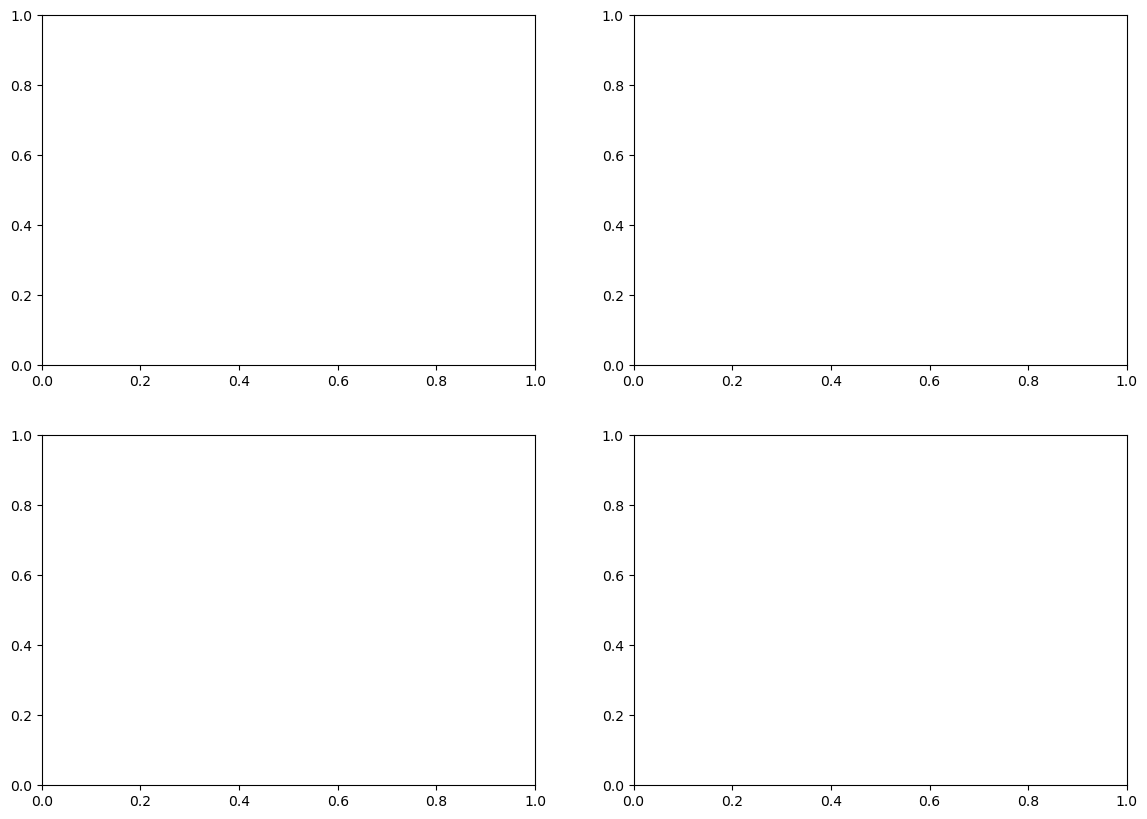

In [57]:
import matplotlib.pyplot as plt
import re
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, timepoint in enumerate(['timepoint_1', 'timepoint_2', 'timepoint_3', 'timepoint_4']):
    ax = axes[i]
    data = filtered[timepoint]
    
    mean_val = data.mean()
    median_val = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    
    sns.histplot(data=data, kde=True, color='skyblue', stat='density', alpha=0.7, ax=ax)
    ax.axvline(x=median_val, color='red', linestyle='--', label=f'Median: {median_val:.2f}s')
    ax.axvline(x=mean_val, color='green', linestyle='-.', label=f'Mean: {mean_val:.2f}s')
    ax.axvline(x=q1, color='purple', linestyle=':', alpha=0.7, label=f'Q1: {q1:.2f}s')
    ax.axvline(x=q3, color='purple', linestyle=':', alpha=0.7, label=f'Q3: {q3:.2f}s')

    ax.set_xlim(left=0, right=5)
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Timepoint {re.search(r"timepoint_()", timepoint).group(1)}', fontsize=12)
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


In [25]:
print(df[df['timepoint_4']>5].shape[0]/df.shape[0]*100)
print(f"95th percentile of timepoint_4: {np.percentile(df['timepoint_4'].dropna(), 95):.4f} seconds")

11.626093736463657
95th percentile of timepoint_4: 6.6987 seconds


In [ ]:
filtered.to_csv('./datasets/df_filtered.csv', sep=';') 

In [ ]:
display(df.describe())

,stage,substage,trial,session,total_trials,ttype_n,stimd_n,y,x,delay_abs,...,STATE_Fixation1_START_last,STATE_Fixation2_START_last,STATE_Fixation3_END,STATE_Response_window_START,STATE_Response_window_END,STATE_Exit_START,timepoint_1,timepoint_2,timepoint_3,timepoint_4
count,547972.000000,547972.000000,547972.000000,547972.000000,547972.000000,547972.000000,547972.000000,547972.000000,547972.000000,547972.000000,...,5.479720e+05,5.479720e+05,5.479720e+05,5.479720e+05,5.479720e+05,5.479620e+05,547972.000000,547972.000000,547972.000000,547972.000000
mean,2.563604,1.597905,53.850073,550.443161,109.527649,1.350702,2.375554,135.078982,200.759309,2.214233,...,1.713024e+09,1.713024e+09,1.713024e+09,1.713024e+09,1.713024e+09,1.713024e+09,13.344162,-0.120331,0.631271,3.260437
std,0.516226,0.853017,42.876221,256.724809,49.452526,1.035228,1.166815,93.367764,115.082897,273.981614,...,8.686310e+06,8.686309e+06,8.686309e+06,8.686309e+06,8.686310e+06,8.686276e+06,345.667569,345.071188,345.065242,439.975099
min,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000,125.000000,60.000000,0.000000,...,1.693965e+09,1.693965e+09,1.693965e+09,1.693965e+09,1.693965e+09,1.693965e+09,0.000200,-167773.388700,-167772.891100,-167772.022200
25%,2.000000,1.000000,20.000000,338.000000,75.000000,1.000000,1.000000,125.000000,60.000000,0.780975,...,1.706294e+09,1.706294e+09,1.706294e+09,1.706294e+09,1.706294e+09,1.706294e+09,5.958200,0.465400,1.106300,2.359400
50%,3.000000,1.000000,44.000000,567.000000,103.000000,1.000000,2.000000,125.000000,200.000000,1.494300,...,1.714385e+09,1.714385e+09,1.714385e+09,1.714385e+09,1.714385e+09,1.714385e+09,9.855700,0.554800,1.275500,2.901500
75%,3.000000,2.000000,78.000000,751.000000,137.000000,2.000000,3.000000,125.000000,340.000000,2.243300,...,1.720982e+09,1.720982e+09,1.720982e+09,1.720982e+09,1.720982e+09,1.720982e+09,14.850425,0.685300,1.503100,3.773100
max,3.000000,3.000000,277.000000,1046.000000,277.000000,4.000000,4.000000,1000.000000,340.000000,167662.035700,...,1.725457e+09,1.725457e+09,1.725457e+09,1.725457e+09,1.725457e+09,1.725457e+09,167778.739200,1675.138800,660.800300,167662.860000


In [ ]:
display(filtered.describe())

,stage,substage,trial,session,total_trials,ttype_n,stimd_n,y,x,delay_abs,...,STATE_Fixation1_START_last,STATE_Fixation2_START_last,STATE_Fixation3_END,STATE_Response_window_START,STATE_Response_window_END,STATE_Exit_START,timepoint_1,timepoint_2,timepoint_3,timepoint_4
count,547867.000000,547867.000000,547867.000000,547867.000000,547867.000000,547867.000000,547867.000000,547867.000000,547867.000000,547867.000000,...,5.478670e+05,5.478670e+05,5.478670e+05,5.478670e+05,5.478670e+05,5.478670e+05,547867.000000,547867.000000,547867.000000,547867.000000
mean,2.563571,1.597955,53.856047,550.411363,109.519507,1.350804,2.375418,135.080914,200.758177,1.687868,...,1.713023e+09,1.713023e+09,1.713023e+09,1.713023e+09,1.713023e+09,1.713023e+09,12.557077,0.665237,1.418113,3.514939
std,0.516223,0.853038,42.876142,256.722591,49.443072,1.035211,1.166788,93.376607,115.082898,1.661686,...,8.685922e+06,8.685922e+06,8.685922e+06,8.685922e+06,8.685921e+06,8.685920e+06,20.630558,1.971780,2.125955,4.042091
min,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000,125.000000,60.000000,0.000000,...,1.693965e+09,1.693965e+09,1.693965e+09,1.693965e+09,1.693965e+09,1.693965e+09,0.000200,0.000900,0.311100,0.695000
25%,2.000000,1.000000,20.000000,338.000000,75.000000,1.000000,1.000000,125.000000,60.000000,0.781600,...,1.706294e+09,1.706294e+09,1.706294e+09,1.706294e+09,1.706294e+09,1.706294e+09,5.959050,0.465400,1.106400,2.359500
50%,3.000000,1.000000,44.000000,567.000000,103.000000,1.000000,2.000000,125.000000,200.000000,1.494500,...,1.714383e+09,1.714383e+09,1.714383e+09,1.714383e+09,1.714383e+09,1.714383e+09,9.856300,0.554800,1.275600,2.901600
75%,3.000000,2.000000,78.000000,751.000000,137.000000,2.000000,3.000000,125.000000,340.000000,2.243400,...,1.720981e+09,1.720981e+09,1.720981e+09,1.720981e+09,1.720981e+09,1.720981e+09,14.850800,0.685300,1.503100,3.773000
max,3.000000,3.000000,277.000000,1046.000000,277.000000,4.000000,4.000000,1000.000000,340.000000,77.622500,...,1.725457e+09,1.725457e+09,1.725457e+09,1.725457e+09,1.725457e+09,1.725457e+09,2071.705500,659.304900,660.800300,1672.347500
